In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb



In [2]:
wandb.login()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: mitalee-garg (mitalee-garg-tu-darmstadt). Use `wandb login --relogin` to force relogin


True

Trained with some changes #200 epochs

In [3]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_3/metrics.csv"
metrics_df = pd.read_csv(file_path)

Plot the AUC-PR curve


In [4]:
# Print available columns to check the correct column name
print("Available columns:", metrics_df.columns)

Available columns: Index(['train_precision_step', 'train_optimal_threshold_step', 'epoch',
       'train_recall_step', 'train_best_f1_step', 'train_auc_pr_step',
       'train_loss_step', 'train_accuracy_step', 'lr-AdamW', 'step',
       ...
       'train_precision/user_9', 'train_precision/user_6',
       'train_recall_epoch', 'train_loss/user_8', 'train_best_f1/user_2',
       'train_loss/user_0', 'train_recall/user_6', 'train_best_f1/user_11',
       'train_precision/user_2', 'train_precision/user_10'],
      dtype='object', length=129)


In [1]:
wandb.init(project="Parcel Delivery", name="graph_logging_run")

# Extract 'train_auc_pr' column, dropping any NaN values
train_auc_pr = metrics_df['train_auc_pr'].dropna().values
epochs = range(1, len(train_auc_pr) + 1)

# Plot AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_auc_pr, marker='o', linestyle='-', color='b', label='Train AUC-PR')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 100 Epochs')
plt.legend()
wandb.log({" AUC-PR Progression Over 100 Epochs": wandb.Image(plt)})

# Show the plot
plt.show()
wandb.finish()

NameError: name 'wandb' is not defined

Smoothing the AOC-PR graph

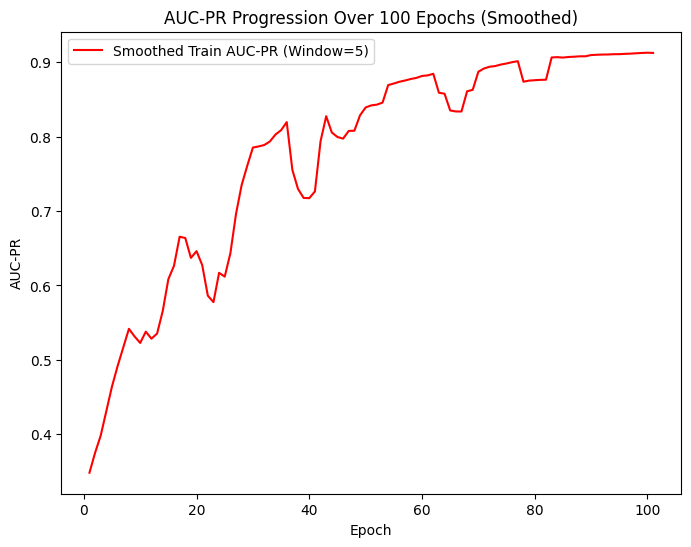

In [6]:
wandb.init(project="Parcel Delivery", name="graph_logging_run")
# Extract 'train_auc_pr' column, dropping any NaN values
train_auc_pr = metrics_df['train_auc_pr_epoch'].dropna().values
epochs = range(1, len(train_auc_pr) + 1)

# Smoothing function (simple moving average)
def smooth(values, window_size):
    smoothed_values = pd.Series(values).rolling(window=window_size, min_periods=1, center=True).mean()
    return smoothed_values

# Apply smoothing with a window size of 5 (adjust as needed)
smoothed_auc_pr = smooth(train_auc_pr, window_size=5)

# Plot original and smoothed AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, smoothed_auc_pr, color='r', label='Smoothed Train AUC-PR (Window=5)')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 100 Epochs (Smoothed)')
plt.legend()
wandb.log({" AUC-PR Progression Over 100 Epochs (Smoothed)": wandb.Image(plt)})

# Show the plot
plt.show()
wandb.finish()

Smotthing the graphs for Score vs Threshold

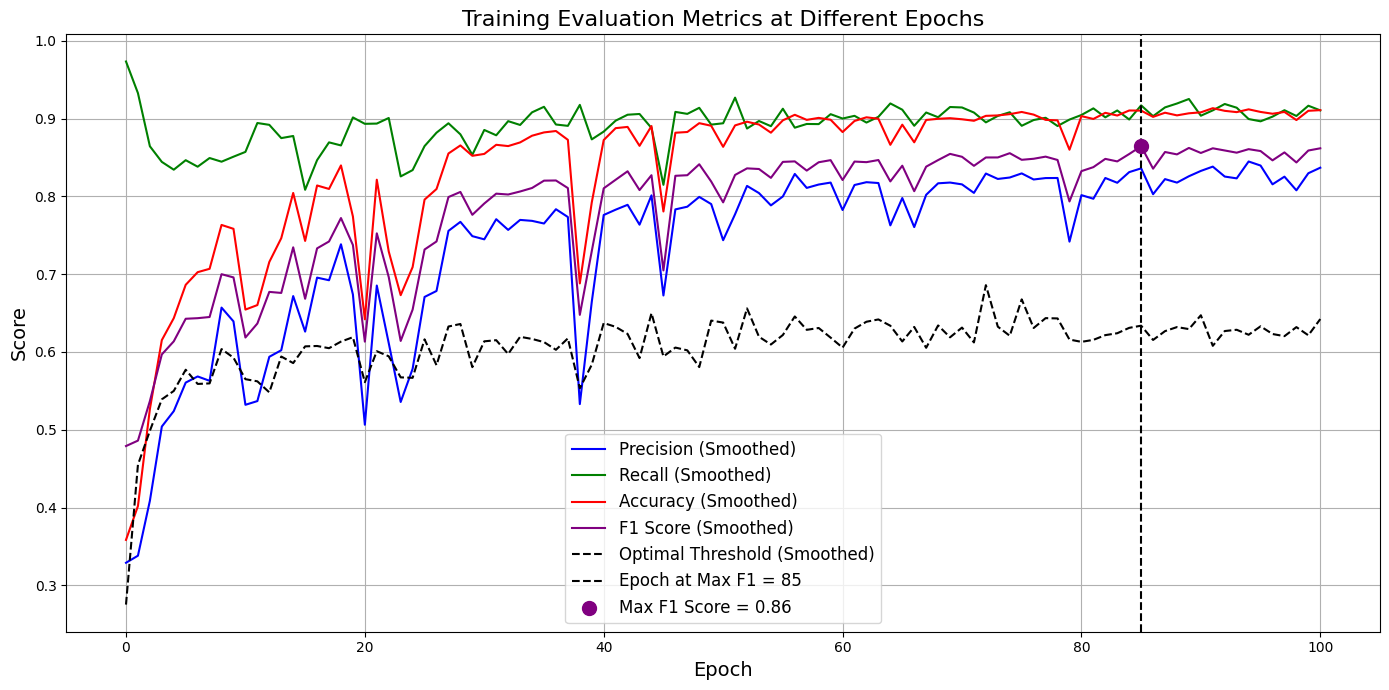

Optimal Threshold: 0.63


In [6]:
import matplotlib.pyplot as plt
import pandas as pd


# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_3/metrics.csv"
metrics_df = pd.read_csv(file_path)

# Group the data by epoch and calculate mean for each metric
grouped_metrics = metrics_df.groupby('epoch').mean()

# Extract epochs and metrics for plotting
epochs = grouped_metrics.index
precision_smooth = grouped_metrics['train_precision_epoch']
recall_smooth = grouped_metrics['train_recall_epoch']
accuracy_smooth = grouped_metrics['train_accuracy_epoch']
f1_smooth = grouped_metrics['train_best_f1_epoch']
threshold_smooth = grouped_metrics['train_optimal_threshold_epoch']

# Find the maximum F1 score and corresponding threshold
max_f1_index = f1_smooth.idxmax()
optimal_threshold = threshold_smooth[max_f1_index]
max_f1_score = f1_smooth[max_f1_index]

# Plot all metrics together
plt.figure(figsize=(14, 7))
plt.plot(epochs, precision_smooth, label='Precision (Smoothed)', color='blue')
plt.plot(epochs, recall_smooth, label='Recall (Smoothed)', color='green')
plt.plot(epochs, accuracy_smooth, label='Accuracy (Smoothed)', color='red')
plt.plot(epochs, f1_smooth, label='F1 Score (Smoothed)', color='purple')
plt.plot(epochs, threshold_smooth, label='Optimal Threshold (Smoothed)', color='black', linestyle='--')

# Highlight the optimal threshold and max F1 score
plt.axvline(x=max_f1_index, color='black', linestyle='--', label=f'Epoch at Max F1 = {max_f1_index:.0f}')
plt.scatter(max_f1_index, max_f1_score, color='purple', s=100, label=f'Max F1 Score = {max_f1_score:.2f}', zorder=5)

# Customize plot labels and grid
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Training Evaluation Metrics at Different Epochs', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

# Print the optimal threshold for reference
print(f"Optimal Threshold: {optimal_threshold:.2f}")
